### 🛎️ Hotel Reservations Dataset - Naive Bayes

# ℹ️ About Dataset

The online hotel reservation channels have dramatically changed booking possibilities and customers’ behavior. A significant number of hotel reservations are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with.

# 🔑 Key Features 

* **Booking_ID** : unique identifier of each booking
* **no_of_adults** : Number of adults
* **no_of_children** : Number of Children
* **no_of_weekend_nights** : Number of weekend nights (Saturday or Sunday) the guest stayed or                              booked to stay at the hotel
* **no_of_week_nights** : Number of week nights (Monday to Friday) the guest stayed or booked                            to stay at the hotel
* **type_of_meal_plan** : Type of meal plan booked by the customer:
* **required_car_parking_space** : Does the customer require a car parking space? (0 - No, 1-                                     Yes)
* **room_type_reserved** : Type of room reserved by the customer. The values are ciphered                                 (encoded) by INN Hotels.
* **lead_time** : Number of days between the date of booking and the arrival date
* **arrival_year** : Year of arrival date
* **arrival_month** : Month of arrival date
* **arrival_date** : Date of the month
* **market_segment_type** : Market segment designation.
* **repeated_guest** : Is the customer a repeated guest? (0 - No, 1- Yes)
* **no_of_previous_cancellations** : Number of previous bookings that were canceled by the                                          customer prior to the current booking
* **no_of_previous_bookings_not_canceled** : Number of previous bookings not canceled by the                                                customer prior to the current booking
* **avg_price_per_room** : Average price per day of the reservation; prices of the rooms are                              dynamic. (in euros)
* **no_of_special_requests** : Total number of special requests made by the customer (e.g.                                    high floor, view from the room, etc)
* **booking_status** : Flag indicating if the booking was canceled or not.

# Problem we want to solve ❓

Predict if the customer is going to honor the reservation or cancel it 


In [22]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.metrics import precision_score , recall_score , f1_score ,accuracy_score
from sklearn.metrics import RocCurveDisplay

# Load Data

In [2]:
data = pd.read_csv(r'C:\Users\stfal\OneDrive\Desktop\MachineLearning\Project-1\Lab4_NaiveBayes\dataset\Hotel Reservations.csv')
#Shuffle data 
data.sample(frac=1).reset_index(drop=True)
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [4]:
data.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [5]:
data.dtypes

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

In [6]:
booking_status = data['booking_status'].value_counts()
booking_status

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

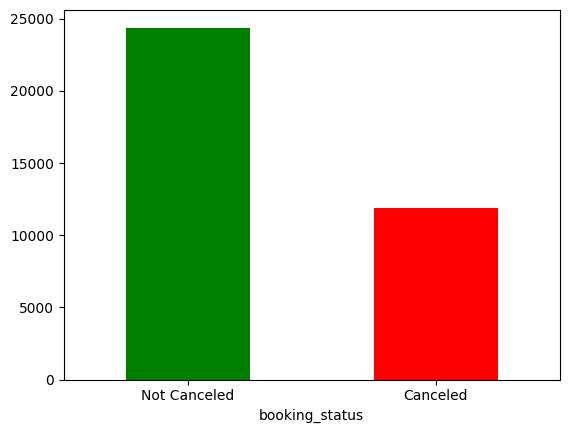

In [7]:
booking_status.plot(kind='bar' , color=['green' , 'red']);
plt.xticks(ticks=[0,1] , rotation=0 , labels=['Not Canceled' , 'Canceled'])
plt.show()

# One Hot Encoding

In [8]:
data = data[:3000]

In [9]:
for column in data.columns :
    if data[column].dtypes == "object" :
        print(column)

Booking_ID
type_of_meal_plan
room_type_reserved
market_segment_type
booking_status


In [10]:
data = data.drop('Booking_ID' , axis=1)
data['type_of_meal_plan'] = [np.argmax((m == np.unique(data['type_of_meal_plan'])).astype(int)) for m in data['type_of_meal_plan']]
data['room_type_reserved'] = [np.argmax((m == np.unique(data['room_type_reserved'])).astype(int)) for m in data['room_type_reserved']]
data['market_segment_type'] = [np.argmax((m == np.unique(data['market_segment_type'])).astype(int)) for m in data['market_segment_type']]
data['booking_status'] = [np.argmax((m == np.unique(data['booking_status'])).astype(int)) for m in data['booking_status']]
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,0,0,0,224,2017,10,2,3,0,0,0,65.00,0,1
1,2,0,2,3,2,0,0,5,2018,11,6,4,0,0,0,106.68,1,1
2,1,0,2,1,0,0,0,1,2018,2,28,4,0,0,0,60.00,0,0
3,2,0,0,2,0,0,0,211,2018,5,20,4,0,0,0,100.00,0,0
4,2,0,1,1,2,0,0,48,2018,4,11,4,0,0,0,94.50,0,0


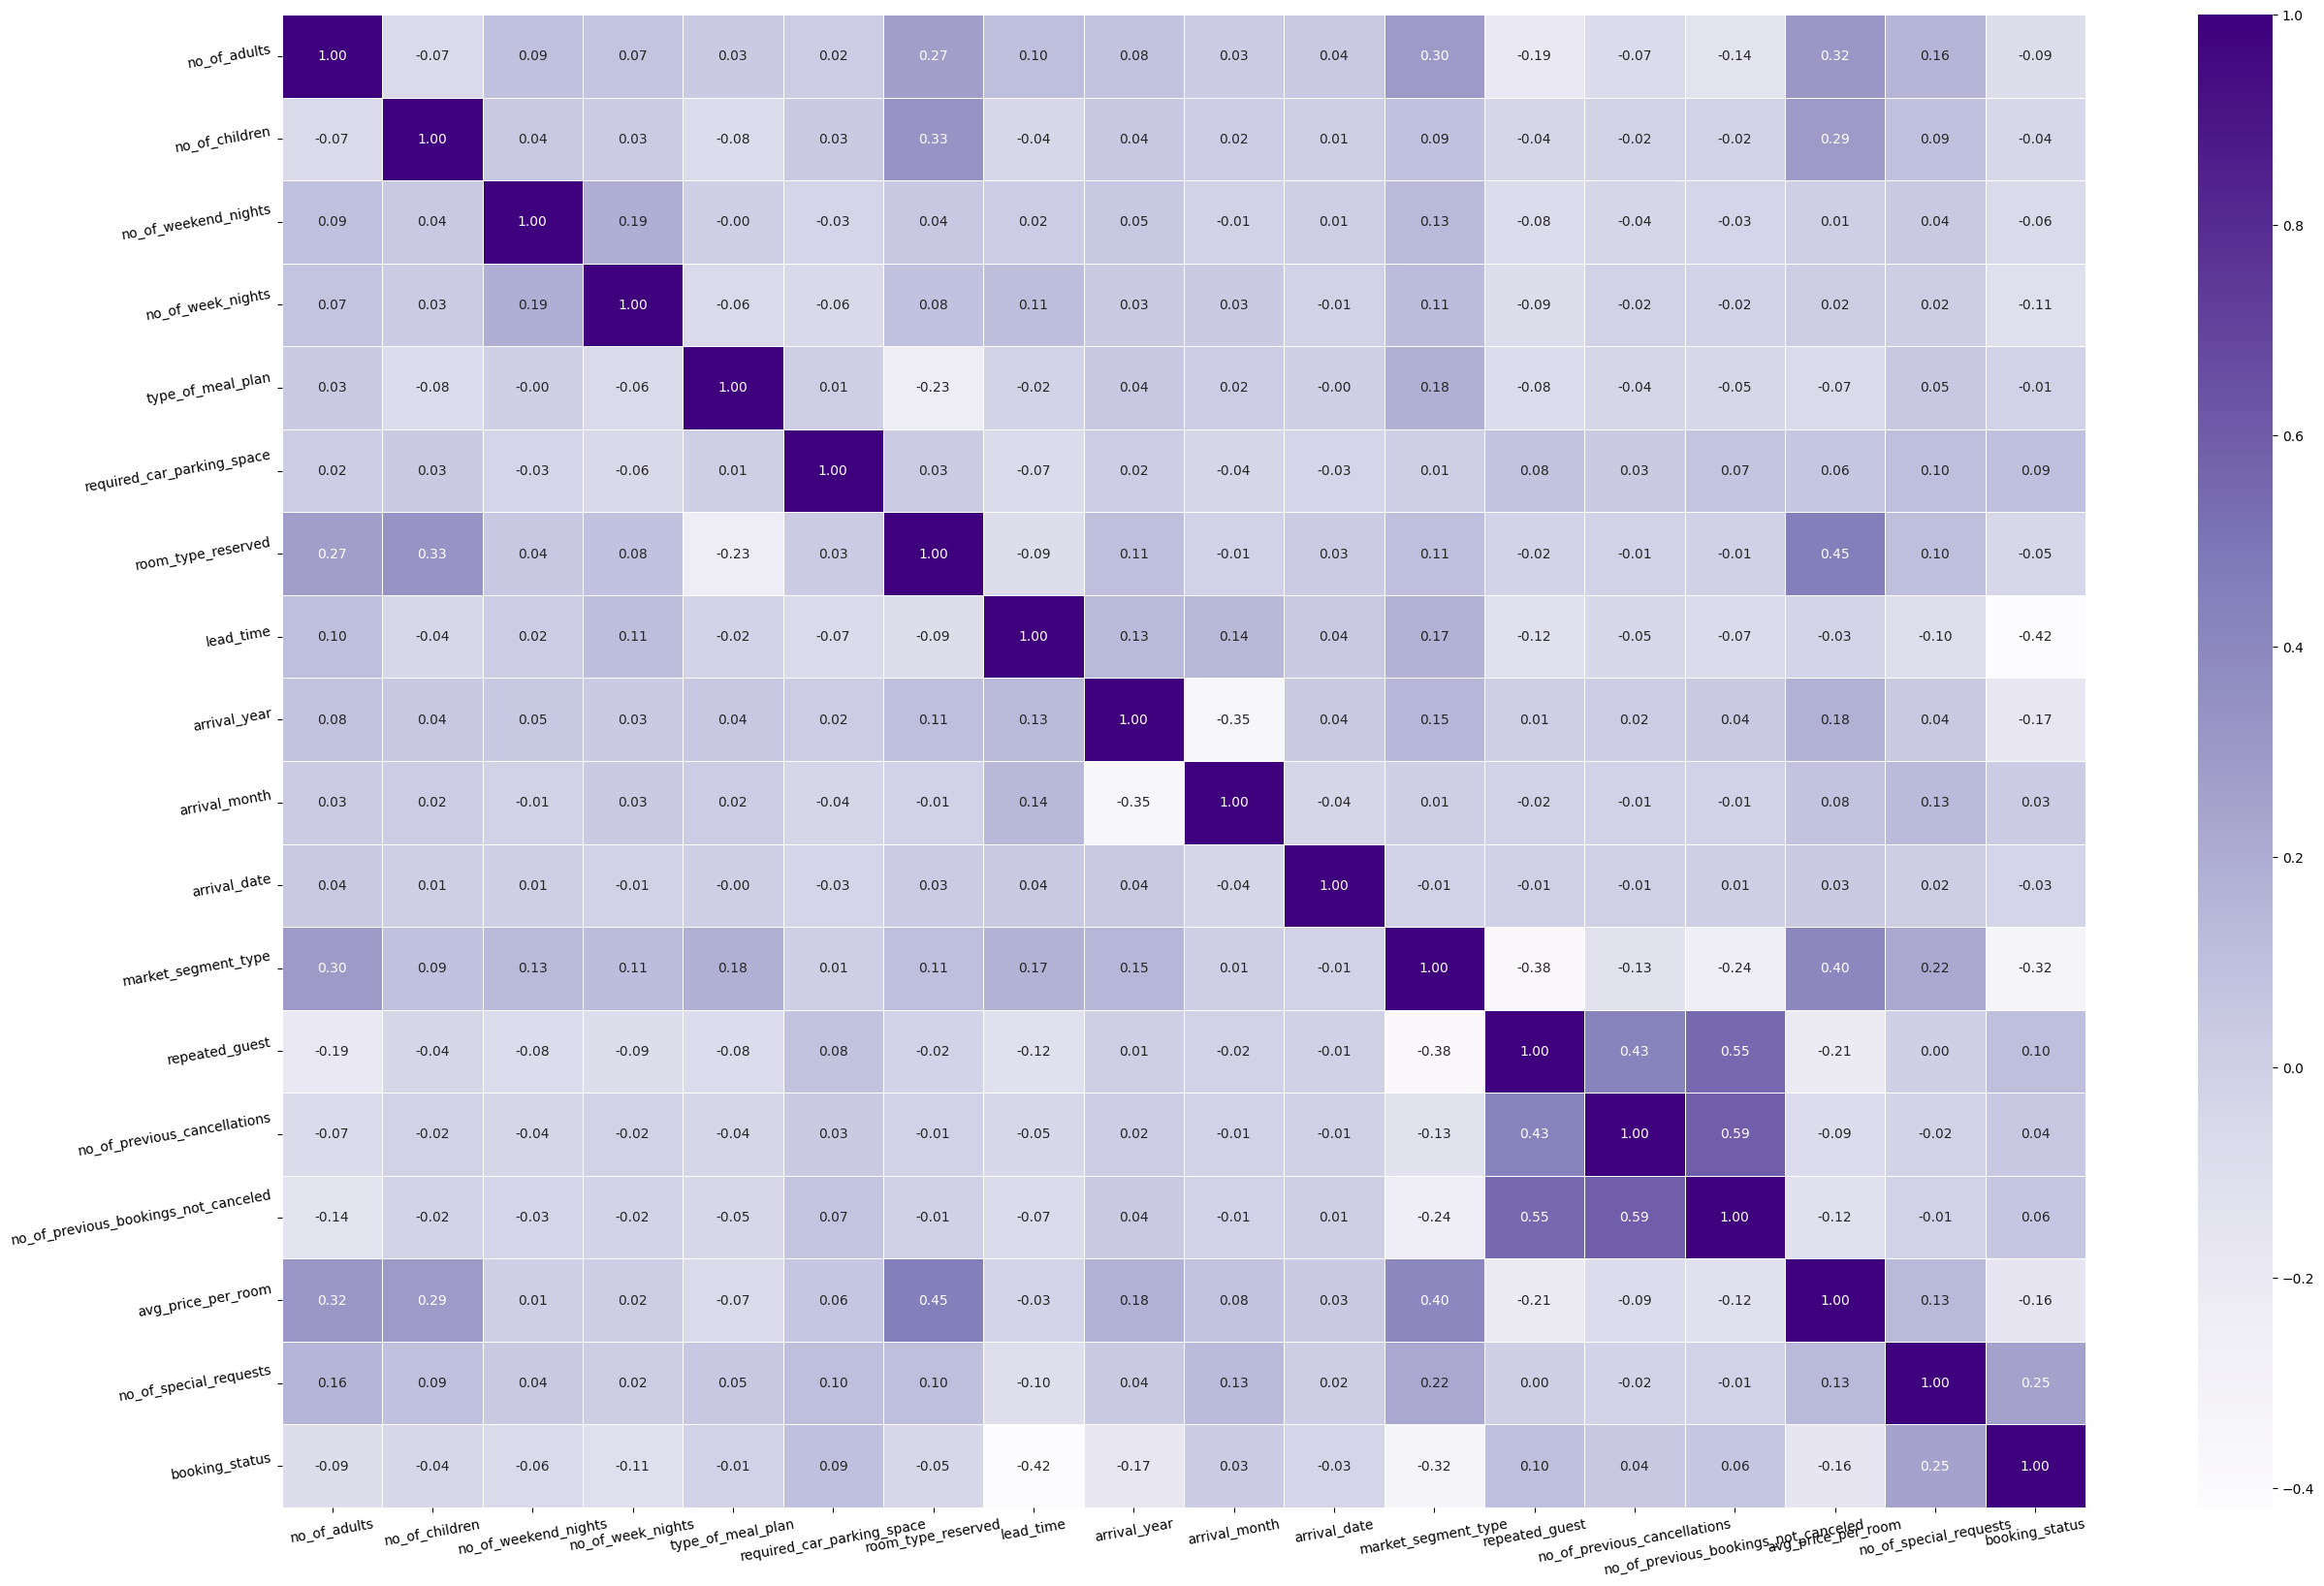

In [11]:
# Corelation Matrix
corr_matrix = data.corr()
fig,ax = plt.subplots(figsize=(30,20));
ax=sns.heatmap(corr_matrix , annot=True , linewidths=0.5 , fmt='.2f' , cmap="Purples");
plt.xticks(rotation=10)
plt.yticks(rotation=10)
plt.show()

# Create X & y and split the data 

In [12]:
X = data.drop('booking_status' , axis=1)
y = data['booking_status']

In [13]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)
len(X_train) , len(y_train) , len(X_test) , len(y_test)

(2400, 2400, 600, 600)

# Gaussian Naive Bayes

In [21]:
from sklearn.naive_bayes import GaussianNB
import time

model = GaussianNB()
start_time = time.time()
model.fit(X_train , y_train)
end_time = time.time() - start_time
train_score = model.score(X_train , y_train)
print(f'Train time : {end_time*1000:.2f} ms')
print(f'Train score : {train_score*100:.2f} %')

Train time : 3.52 ms
Train score : 39.58 %


In [23]:
y_pred = model.predict(X_test)
report = classification_report(y_test , y_pred)
print(report)
accuracy_gaussian = accuracy_score(y_test , y_pred)

              precision    recall  f1-score   support

           0       0.39      0.97      0.56       220
           1       0.89      0.13      0.23       380

    accuracy                           0.44       600
   macro avg       0.64      0.55      0.39       600
weighted avg       0.71      0.44      0.35       600



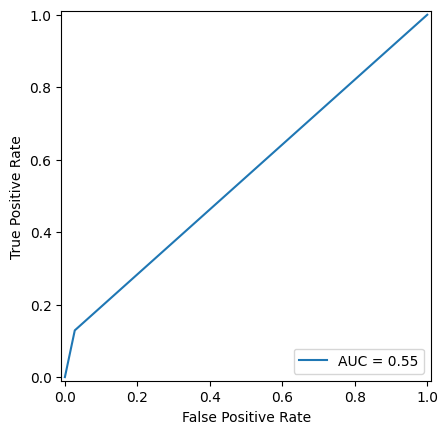

In [24]:
# PLot ROC curve and calculate AUC metric
from sklearn import metrics

fpr , tpr , thresholds = metrics.roc_curve(y_test , y_pred)
roc_auc = metrics.auc(fpr,tpr)
display = metrics.RocCurveDisplay(fpr=fpr , tpr=tpr , roc_auc=roc_auc)
display.plot()
plt.show();

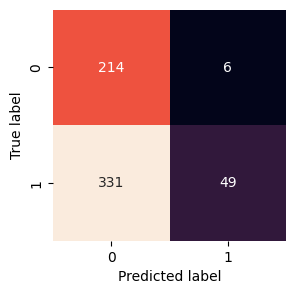

In [25]:
fig,ax = plt.subplots(figsize=(3,3))
ax = sns.heatmap(confusion_matrix(y_test,y_pred),
                     annot=True,
                     fmt='d',
                     cbar=False)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show();    

# Multinomial Naive Bayes

In [26]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
start_time = time.time()
model.fit(X_train , y_train)
end_time = time.time() - start_time
train_score = model.score(X_train , y_train)

print(f'Train time : {end_time*1000:.2f} ms')
print(f'Train score : {train_score*100:.2f}%')

Train time : 29.43 ms
Train score : 71.25%


In [29]:
y_pred = model.predict(X_test)
report = classification_report(y_test , y_pred)
accuracy_multinomial = accuracy_score(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.66      0.58      0.62       220
           1       0.77      0.82      0.80       380

    accuracy                           0.73       600
   macro avg       0.71      0.70      0.71       600
weighted avg       0.73      0.73      0.73       600



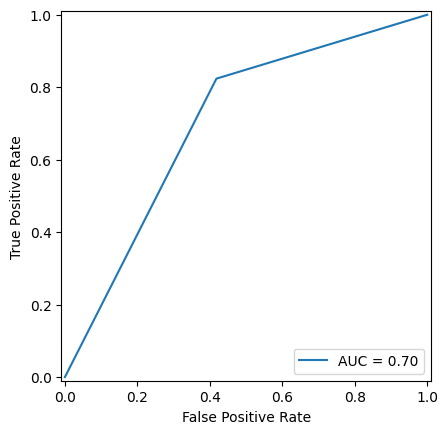

In [30]:
fpr , tpr , thresholds = metrics.roc_curve(y_test , y_pred)
roc_auc = metrics.auc(fpr,tpr)
display = metrics.RocCurveDisplay(fpr=fpr , tpr=tpr , roc_auc=roc_auc)
display.plot()
plt.show();

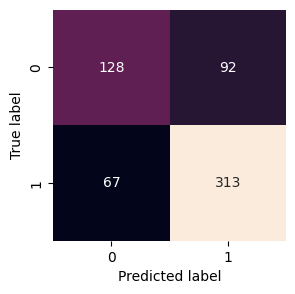

In [31]:
fig,ax = plt.subplots(figsize=(3,3))
ax = sns.heatmap(confusion_matrix(y_test , y_pred) , annot=True , fmt='d' , cbar=False)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Bernoulli Naive Bayes

In [32]:
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()
start_time = time.time()
model.fit(X_train , y_train)
end_time = time.time() - start_time
train_score = model.score(X_train , y_train)

print(f'Train Time : {end_time*1000:.2f} ms')
print(f'Train Score : {train_score*100:.1f}%')

Train Time : 23.43 ms
Train Score : 69.8%


In [33]:
y_pred = model.predict(X_test)
report = classification_report(y_test , y_pred)
print(report)
accuracy_bernoulli = accuracy_score(y_test , y_pred)

              precision    recall  f1-score   support

           0       0.70      0.14      0.23       220
           1       0.66      0.97      0.78       380

    accuracy                           0.66       600
   macro avg       0.68      0.55      0.51       600
weighted avg       0.67      0.66      0.58       600



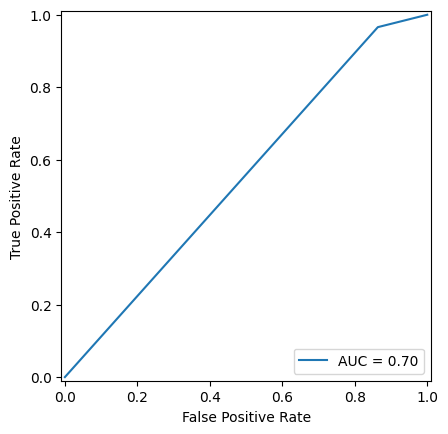

In [36]:
fpr , tpr , thresholds = metrics.roc_curve(y_test , y_pred)
roc_auc - metrics.auc(fpr , tpr)
display = metrics.RocCurveDisplay(fpr=fpr , tpr=tpr , roc_auc=roc_auc)
display.plot()
plt.show();

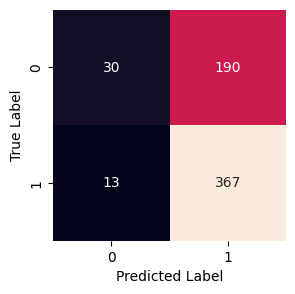

In [42]:
fig,ax = plt.subplots(figsize=(3,3))
ax = sns.heatmap(confusion_matrix(y_test , y_pred) , annot=True , fmt='d' , cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Compare Gaussian , Multinomial & Bernoulli

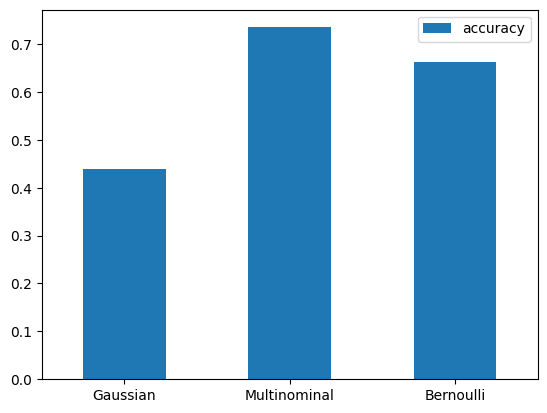

In [44]:
model_scores = {'Gaussian' : accuracy_gaussian , 'Multinominal' : accuracy_multinomial , 'Bernoulli' : accuracy_bernoulli}

model_compare = pd.DataFrame(model_scores , index=['accuracy'])
model_compare.T.plot.bar()
plt.xticks(rotation=0)
plt.show()